In [1]:
!virtualenv aor_submission

PermissionError: [WinError 5] Access is denied: 'C:\\Users\\bogda\\Desktop\\projects\\python\\analytics_cup_research\\aor_submission\\Scripts\\python.exe'


In [2]:
!aor_submission\Scripts\activate

In [3]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np

from src.utils import *
from src.data_processing import *
from src.chains_data_processing import *
from src.feature_creation import *

In [5]:
match_ids = [
    1886347,
    1899585,
    1925299,
    1953632,
    1996435,    
    2006229,
    2011166,
    2013725,
    2015213,
    2017461,
]

pitch_width = 105
pitch_height = 68

skillcorner_opendata_media_url = "https://media.githubusercontent.com/media/SkillCorner/opendata/master/data/matches/"
skillcorner_opendata_raw_url = "https://raw.githubusercontent.com/SkillCorner/opendata/master/data/matches/"

skillcorner = SkillCornerData()
fc = FeatureCreation()
cdp = GKChains()
utils = Utils()

In [6]:
td_list = skillcorner.prepare_tracking_data_files(skillcorner_opendata_media_url, match_ids=match_ids)
td_df = skillcorner.load_tracking_data(td_list)
td_df = skillcorner.process_tracking_data_dataframe(td_df)

pm_list = skillcorner.prepare_metadata_files(skillcorner_opendata_raw_url, match_ids=match_ids)
pm_df = skillcorner.load_metadata(pm_list)
pm_df = skillcorner.process_players_metadata_dataframe(pm_df)

de_list = skillcorner.prepare_dynamic_events_files(skillcorner_opendata_raw_url, match_ids=match_ids)
de_df = skillcorner.load_dynamic_events_data(de_list)
de_df = skillcorner.filter_player_possessions(de_df)

c:\Users\bogda\Desktop\projects\python\analytics_cup_research\src\data_processing.py:137: DtypeWarning: Columns (276) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.concat(
c:\Users\bogda\Desktop\projects\python\analytics_cup_research\src\data_processing.py:137: DtypeWarning: Columns (75,77,184,264) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.concat(


In [7]:
# Step 7: Analyze all possession chains
gk_chains = []
i = 0

for (match_id, chain_id), chain_group in de_df.groupby(['match_id', 'possession_chain_id']):
    chain_result = cdp.analyze_gk_chain(chain_group, i)
    i += 1
    if chain_result:
        gk_chains.append(chain_result)

# Convert to DataFrame
gk_chains_df = pd.DataFrame(gk_chains)

In [8]:
cdp.get_gk_chains_info(gk_chains_df=gk_chains_df)


=== GK-Started Possession Chain Analysis ===
Total GK-started chains: 119

Chains reaching attacking third: 24 (20.2%)
Chains ending in attacking third: 21 (17.6%)

=== Chain Outcomes ===
end_type
pass               93
possession_loss    18
shot                6
foul_suffered       1
clearance           1
Name: count, dtype: int64

=== For chains reaching attacking third ===
Total: 24

How they ended:
end_type
pass               12
shot                6
possession_loss     5
foul_suffered       1
Name: count, dtype: int64

Led to shot: 6
Led to goal: 1

Average chain length: 8.4 possessions

=== Starting Phase Distribution ===
start_phase
build_up      70
create        24
direct        11
chaotic        9
disruption     3
transition     2
Name: count, dtype: int64

=== Average Chain Length by Outcome ===
                             mean  median  min  max
reached_attacking_third                            
False                    4.821053     4.0    1   17
True                     8.

In [9]:
synced_df = gk_chains_df.merge(
    td_df,
    left_on=["frame_end"],
    right_on="frame",
    suffixes=("_event", "_tracking")
)

In [10]:
synced_df.head()

,match_id,frame_start,frame_end,possession_chain_id,team_id,team_name,chain_length,x_start,x_end,y_start,...,possession_index,x,y,player_id,is_detected,frame,timestamp,period,possession_player_id,possession_group
0,1886347,387,430,5,1805,Newcastle,3,-47.3,-42.28,-2.23,...,4,-42.28,-0.41,51009,True,430,2025-12-27 00:00:42,1.0,51009.0,away team
1,1886347,387,430,5,1805,Newcastle,3,-47.3,-42.28,-2.23,...,4,-44.81,-13.35,176224,True,430,2025-12-27 00:00:42,1.0,51009.0,away team
2,1886347,387,430,5,1805,Newcastle,3,-47.3,-42.28,-2.23,...,4,-46.19,5.38,51649,True,430,2025-12-27 00:00:42,1.0,51009.0,away team
3,1886347,387,430,5,1805,Newcastle,3,-47.3,-42.28,-2.23,...,4,-31.93,-22.36,50983,True,430,2025-12-27 00:00:42,1.0,51009.0,away team
4,1886347,387,430,5,1805,Newcastle,3,-47.3,-42.28,-2.23,...,4,-43.20,20.02,735578,True,430,2025-12-27 00:00:42,1.0,51009.0,away team


In [11]:
utils.apply_coords_to_df(synced_df, pitch_width, pitch_height)

,match_id,frame_start,frame_end,possession_chain_id,team_id,team_name,chain_length,x_start,x_end,y_start,...,player_id,is_detected,frame,timestamp,period,possession_player_id,possession_group,x1,c1,y1
0,1886347,387,430,5,1805,Newcastle,3,-47.30,-42.28,-2.23,...,51009,True,430,2025-12-27 00:00:42.000,1.0,51009.0,away team,10.7310,11.1588,45.1588
1,1886347,387,430,5,1805,Newcastle,3,-47.30,-42.28,-2.23,...,176224,True,430,2025-12-27 00:00:42.000,1.0,51009.0,away team,8.0745,19.9580,53.9580
2,1886347,387,430,5,1805,Newcastle,3,-47.30,-42.28,-2.23,...,51649,True,430,2025-12-27 00:00:42.000,1.0,51009.0,away team,6.6255,7.2216,41.2216
3,1886347,387,430,5,1805,Newcastle,3,-47.30,-42.28,-2.23,...,50983,True,430,2025-12-27 00:00:42.000,1.0,51009.0,away team,21.5985,26.0848,60.0848
4,1886347,387,430,5,1805,Newcastle,3,-47.30,-42.28,-2.23,...,735578,True,430,2025-12-27 00:00:42.000,1.0,51009.0,away team,9.7650,2.7336,31.2664
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17793,2017461,69508,69541,239,868,Melbourne V FC,12,-46.89,-45.79,1.90,...,159688,True,69541,2025-12-27 01:34:47.100,2.0,51678.0,home team,100.8630,4.6240,38.6240
17794,2017461,69508,69541,239,868,Melbourne V FC,12,-46.89,-45.79,1.90,...,51714,False,69541,2025-12-27 01:34:47.100,2.0,51678.0,home team,63.0210,0.5032,34.5032
17795,2017461,69508,69541,239,868,Melbourne V FC,12,-46.89,-45.79,1.90,...,795521,False,69541,2025-12-27 01:34:47.100,2.0,51678.0,home team,84.8610,3.3592,37.3592
17796,2017461,69508,69541,239,868,Melbourne V FC,12,-46.89,-45.79,1.90,...,745320,False,69541,2025-12-27 01:34:47.100,2.0,51678.0,home team,52.2480,19.7880,53.7880


In [12]:
model_features_df = fc.create_features_dataframe(synced_df.possession_index.unique(), synced_df)

In [13]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

test_model1 = smf.glm(formula="gk_led_to_final_third ~ d2 + max_x_reached ",
                      data = model_features_df,
                      family = sm.families.Binomial()).fit()

print(test_model1.summary())

                   Generalized Linear Model Regression Results                   
Dep. Variable:     gk_led_to_final_third   No. Observations:                  119
Model:                               GLM   Df Residuals:                      116
Model Family:                   Binomial   Df Model:                            2
Link Function:                     Logit   Scale:                          1.0000
Method:                             IRLS   Log-Likelihood:                -58.833
Date:                   Sat, 27 Dec 2025   Deviance:                       117.67
Time:                           16:25:11   Pearson chi2:                     120.
No. Iterations:                        4   Pseudo R-squ. (CS):            0.01651
Covariance Type:               nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       

In [14]:
X_train, X_test, y_train, y_test = train_test_split(model_features_df[test_model1.params.keys()[1:]], model_features_df['gk_led_to_final_third'], test_size=0.33, random_state=42)

# Train the RandomForest classifier
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

# Predict probabilities for the test set
y_probs = clf.predict_proba(model_features_df[test_model1.params.keys()[1:]])[::, 1]

model_features_df["GKLaunch"] = y_probs

ROC-AUC Score: 0.82


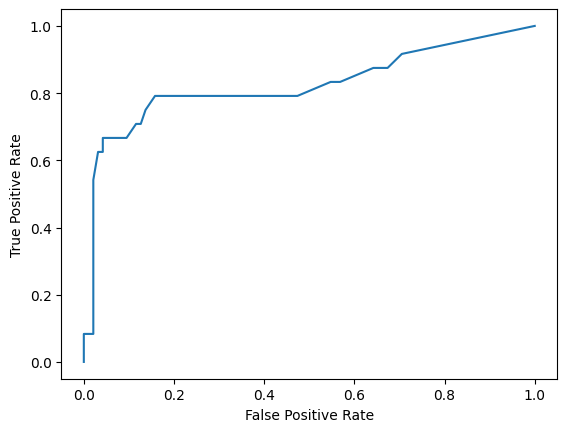

In [15]:
utils.roc(model_features_df['gk_led_to_final_third'], y_probs=y_probs)

In [16]:
result_df = model_features_df.groupby(["gkId"])["GKLaunch"].sum().sort_values(ascending=False).reset_index()
result_df = result_df.merge(
    pm_df,
    how="left",
    left_on=["gkId"],
    right_on=["id"]
)

In [17]:
fc.add_normalized_metrics_to_dataframe(result_df)

In [18]:
result_df.sort_values('GKLaunchPer90', ascending=False)

,gkId,GKLaunch,id,short_name,team_id,team_name,total_minutes_played,total_minutes_played_tip,total_minutes_played_otip,player_role.acronym,GKLaunchPer90,GKLaunchPer30TIP,GKLaunchPer30OTIP
1,51009,6.81,51009,R. Scott,1805,Newcastle United Jets FC,98.40,22.20,31.13,GK,6.23,9.20,6.56
0,285188,11.15,285188,A. Paulsen,4177,Auckland FC,396.50,103.63,98.72,GK,2.53,3.23,3.39
2,34718,2.23,34718,J. Oluwayemi,867,Wellington Phoenix FC,199.67,46.61,49.12,GK,1.01,1.44,1.36
4,50999,0.90,50999,M. Freke,1802,Brisbane Roar FC,102.13,37.19,22.84,GK,0.79,0.73,1.18
3,931987,1.09,931987,H. Devenish-Meares,869,Sydney Football Club,190.65,56.93,49.56,GK,0.51,0.57,0.66
5,560985,0.27,560985,C. Cook,871,Perth Glory Football Club,102.13,22.84,37.19,GK,0.24,0.35,0.22
